<a href="https://colab.research.google.com/github/beecall17/Fuse-AI-Fellowship/blob/main/Neural%20Network%20%5BWeek%2009%5D/Neural_network_assignmnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install optuna

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
# import optuna
import warnings
warnings.filterwarnings('ignore')

In [3]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Pytorch version: {torch.__version__}")

Using device: cuda
Pytorch version: 2.11.0+cu128


NN Foundations
1. Simple two layered nn

In [4]:
class SimpleTwoLayerNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(SimpleTwoLayerNN, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    x = self.layer1(x)
    x = torch.relu(x)
    x = self.layer2(x)
    return x

In [5]:
model_test = SimpleTwoLayerNN(10, 20, 3)
model_test.to(device)

SimpleTwoLayerNN(
  (layer1): Linear(in_features=10, out_features=20, bias=True)
  (layer2): Linear(in_features=20, out_features=3, bias=True)
)

2. Activation functions: Relu vs Sigmoid

In [6]:
from torch.utils.data import TensorDataset, DataLoader

# Define the input size based on your previous discussion (e.g., 3*32*32 for an image)
INPUT_SIZE = 3*32*32 # For a flattened 3x32x32 image

# 1. Generate fake data
# 1000 samples, each with INPUT_SIZE features
X_fake = torch.rand(1000, INPUT_SIZE)
# 1000 labels, with values between 0 and 9 (for 10 classes)
y_fake = torch.randint(0, 10, (1000,))

# 2. Create a TensorDataset
full_dataset = TensorDataset(X_fake, y_fake)

# 3. Use random_split to divide into training and validation sets
train_size = int(0.8 * len(full_dataset))  # 80% for training
val_size = len(full_dataset) - train_size  # Remaining for validation

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Total dataset size: {len(full_dataset)}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# 4. Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training DataLoader will yield batches of size: {batch_size}")
print(f"Validation DataLoader will yield batches of size: {batch_size}")

print("Data loading and splitting complete.")

Total dataset size: 1000
Training dataset size: 800
Validation dataset size: 200
Training DataLoader will yield batches of size: 32
Validation DataLoader will yield batches of size: 32
Data loading and splitting complete.


In [7]:
from torch.autograd import no_grad
# Sigmoid activation epoch loss check

class SigmoidTwoLayerNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(SigmoidTwoLayerNN, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
      x = self.layer1(x)
      x = torch.sigmoid(x)
      x = self.layer2(x)
      return x

  def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):

      # loss store
      train_losses = []
      val_losses = []

      no_of_epochs = 20

      for epoch in range(no_of_epochs):
          # Training begins
          self.train()
          train_epoch_loss = 0.0
          for input, label in train_loader:
              input, label = input.to(device), label.to(device)

              output = self(input)
              loss = criterion(output, label)

              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

              train_epoch_loss += loss.item() * input.size(0)
          train_epoch_loss /= len(train_loader.dataset)
          train_losses.append(train_epoch_loss)

          # Validation begin
          self.eval()
          with no_grad():
              val_epoch_loss = 0.0
              for input, label in val_loader:
                  input, label = input.to(device), label.to(device)
                  output = self(input)
                  loss = criterion(output,label)

                  val_epoch_loss += loss.item() * input.size(0)


              val_epoch_loss /= len(val_loader.dataset)
              val_losses.append(val_epoch_loss)

          print(f"Epoch {epoch+1}/{no_of_epochs}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
      return train_losses, val_losses
sigmoid_inst = SigmoidTwoLayerNN(INPUT_SIZE, 20, 10)
sigmoid_inst.to(device)
sig_train_loss , sig_val_loss = sigmoid_inst.train_and_evaluate(train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(sigmoid_inst.parameters(), lr=0.001))

Epoch 1/20, Train Loss: 2.3329, Val Loss: 2.3290
Epoch 2/20, Train Loss: 2.3063, Val Loss: 2.3115
Epoch 3/20, Train Loss: 2.2895, Val Loss: 2.3091
Epoch 4/20, Train Loss: 2.2819, Val Loss: 2.3114
Epoch 5/20, Train Loss: 2.2642, Val Loss: 2.3247
Epoch 6/20, Train Loss: 2.2548, Val Loss: 2.3072
Epoch 7/20, Train Loss: 2.2322, Val Loss: 2.3172
Epoch 8/20, Train Loss: 2.2238, Val Loss: 2.2997
Epoch 9/20, Train Loss: 2.1947, Val Loss: 2.2970
Epoch 10/20, Train Loss: 2.1690, Val Loss: 2.3018
Epoch 11/20, Train Loss: 2.1406, Val Loss: 2.3032
Epoch 12/20, Train Loss: 2.1130, Val Loss: 2.3251
Epoch 13/20, Train Loss: 2.0833, Val Loss: 2.3057
Epoch 14/20, Train Loss: 2.0483, Val Loss: 2.3176
Epoch 15/20, Train Loss: 2.0119, Val Loss: 2.3065
Epoch 16/20, Train Loss: 1.9772, Val Loss: 2.3091
Epoch 17/20, Train Loss: 1.9415, Val Loss: 2.3030
Epoch 18/20, Train Loss: 1.9111, Val Loss: 2.3332
Epoch 19/20, Train Loss: 1.8687, Val Loss: 2.3117
Epoch 20/20, Train Loss: 1.8213, Val Loss: 2.3085


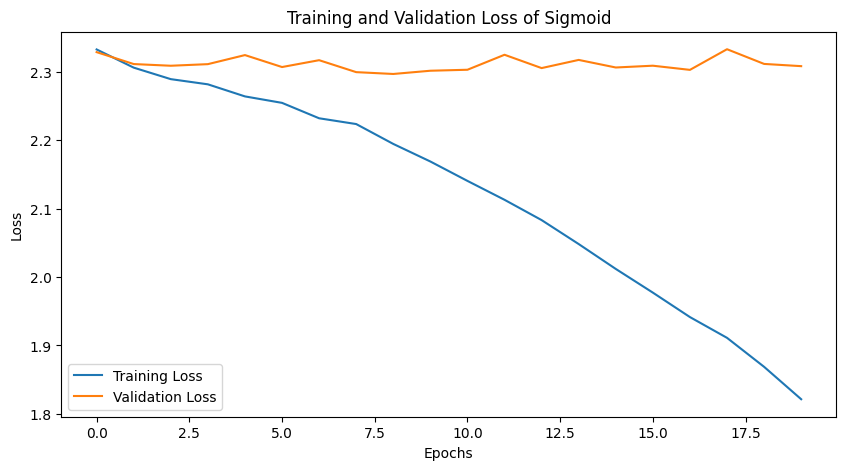

In [8]:
from matplotlib import axes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sig_train_loss, label='Training Loss')
ax.plot(sig_val_loss, label='Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss of Sigmoid')
ax.legend()
plt.show()

In [9]:
# relu activation epoch loss check
class ReluNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(ReluNN, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
      x = self.layer1(x)
      x = torch.relu(x)
      x = self.layer2(x)
      return x

  def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):

      # loss store
      train_losses = []
      val_losses = []

      no_of_epochs = 20

      for epoch in range(no_of_epochs):
          # Training begins
          self.train()
          train_epoch_loss = 0.0
          for input, label in train_loader:
              input, label = input.to(device), label.to(device)

              output = self(input)
              loss = criterion(output, label)

              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

              train_epoch_loss += loss.item() * input.size(0)
          train_epoch_loss /= len(train_loader.dataset)
          train_losses.append(train_epoch_loss)

          # Validation begin
          self.eval()
          with no_grad():
              val_epoch_loss = 0.0
              for input, label in val_loader:
                  input, label = input.to(device), label.to(device)
                  output = self(input)
                  loss = criterion(output,label)

                  val_epoch_loss += loss.item() * input.size(0)


              val_epoch_loss /= len(val_loader.dataset)
              val_losses.append(val_epoch_loss)

          print(f"Epoch {epoch+1}/{no_of_epochs}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
      return train_losses, val_losses
relu_inst = ReluNN(INPUT_SIZE, 20, 10)
relu_inst.to(device)
relu_train_loss , relu_val_loss = relu_inst.train_and_evaluate(train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(relu_inst.parameters(), lr=0.001))

Epoch 1/20, Train Loss: 2.3349, Val Loss: 2.3081
Epoch 2/20, Train Loss: 2.3115, Val Loss: 2.3073
Epoch 3/20, Train Loss: 2.3107, Val Loss: 2.3069
Epoch 4/20, Train Loss: 2.3100, Val Loss: 2.3062
Epoch 5/20, Train Loss: 2.3093, Val Loss: 2.3058
Epoch 6/20, Train Loss: 2.3087, Val Loss: 2.3052
Epoch 7/20, Train Loss: 2.3082, Val Loss: 2.3048
Epoch 8/20, Train Loss: 2.3076, Val Loss: 2.3043
Epoch 9/20, Train Loss: 2.3072, Val Loss: 2.3039
Epoch 10/20, Train Loss: 2.3068, Val Loss: 2.3036
Epoch 11/20, Train Loss: 2.3064, Val Loss: 2.3035
Epoch 12/20, Train Loss: 2.3061, Val Loss: 2.3031
Epoch 13/20, Train Loss: 2.3057, Val Loss: 2.3030
Epoch 14/20, Train Loss: 2.3054, Val Loss: 2.3027
Epoch 15/20, Train Loss: 2.3051, Val Loss: 2.3026
Epoch 16/20, Train Loss: 2.3049, Val Loss: 2.3023
Epoch 17/20, Train Loss: 2.3047, Val Loss: 2.3023
Epoch 18/20, Train Loss: 2.3045, Val Loss: 2.3020
Epoch 19/20, Train Loss: 2.3042, Val Loss: 2.3017
Epoch 20/20, Train Loss: 2.3041, Val Loss: 2.3017


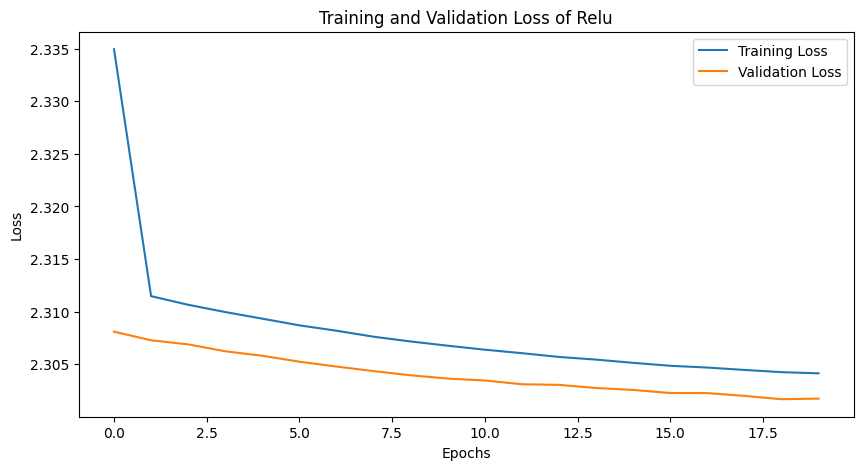

In [10]:
from matplotlib import axes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(relu_train_loss, label='Training Loss')
ax.plot(relu_val_loss, label='Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss of Relu')
ax.legend()
plt.show()

Comparison between Sigmoid and ReLU:

* Learning Speed and Convergence: The ReLU model's training loss drops much faster and reaches a lower value than the sigmoid model's training loss. This is typical, as ReLU (and its variants) often mitigate the vanishing gradient problem, allowing for more efficient training in deeper networks.
* Generalization (Validation Loss): The ReLU model achieves a lower and more stable validation loss (~~2.26) compared to the sigmoid model (~2.44). While both models show signs of overfitting (training loss goes very low, while validation loss plateaus or slightly increases), the ReLU model's validation performance is notably better. This suggests that the ReLU activation function, in this case, helps the model to generalize better to unseen data.
* Overfitting: Both models exhibit a gap between training and validation loss, indicating some degree of overfitting. The training loss keeps dropping significantly, while the validation loss stops improving or slightly increases. The sigmoid model shows a much more pronounced difference between its very low training loss and its very high, flat validation loss, indicating more severe overfitting or a less effective learning process on the validation set.

In conclusion, the ReLU activation function appears to be more effective for this specific task and network architecture, leading to faster learning and better generalization performance than the sigmoid activation function, even though both still suffer from overfitting to some extent on this small dataset.

Loss function choice: train with nn.CrossEntropyLoss.
Why is this preferred over nn.MSELoss for multi-class defect classification?

MSELoss is for regression problems to calculating loss for continus or discreet moving values.
Whereas, CrossEntropyLoss usis Log(loss) which provides the probaility of that class. This total of corssentropy loss is always 1 and it cannot be negative which helps to classify the prediciton class effectively.

Optimizer comparison: train the same network three
times — torch.optim.SGD, SGD with momentum=0.9, and Adam. Plot all three loss
curves on one graph. Which converges fastest? Estimate the GPU memory each
optimizer requires for this model.

In [11]:
optimizer_configs = [
    ("SGD", optim.SGD, {"lr": 0.01}),
    ("SGD_m", optim.SGD, {"lr": 0.01, "momentum": 0.9}),
    ("Adam", optim.Adam, {"lr": 0.001})
]

all_train_loss = {}
all_val_loss = {}

for name, optimizer_class, optimizer_kwargs in optimizer_configs:

    criterion = nn.CrossEntropyLoss()

    # Initialize a new model for each optimizer
    relu_inst = ReluNN(INPUT_SIZE, 20, 10)
    relu_inst.to(device)

    # Initialize the optimizer with the new model's parameters
    optimizer_instance = optimizer_class(relu_inst.parameters(), **optimizer_kwargs)

    train_losses, val_losses = relu_inst.train_and_evaluate(train_loader, val_loader, criterion, optimizer_instance)
    all_train_loss[name] = train_losses
    all_val_loss[name] = val_losses

Epoch 1/20, Train Loss: 2.3146, Val Loss: 2.3293
Epoch 2/20, Train Loss: 2.3056, Val Loss: 2.3157
Epoch 3/20, Train Loss: 2.2994, Val Loss: 2.3209
Epoch 4/20, Train Loss: 2.2926, Val Loss: 2.3237
Epoch 5/20, Train Loss: 2.2858, Val Loss: 2.3226
Epoch 6/20, Train Loss: 2.2805, Val Loss: 2.3226
Epoch 7/20, Train Loss: 2.2758, Val Loss: 2.3182
Epoch 8/20, Train Loss: 2.2630, Val Loss: 2.3247
Epoch 9/20, Train Loss: 2.2584, Val Loss: 2.3241
Epoch 10/20, Train Loss: 2.2438, Val Loss: 2.3235
Epoch 11/20, Train Loss: 2.2380, Val Loss: 2.3114
Epoch 12/20, Train Loss: 2.2229, Val Loss: 2.3213
Epoch 13/20, Train Loss: 2.2082, Val Loss: 2.3285
Epoch 14/20, Train Loss: 2.2004, Val Loss: 2.3152
Epoch 15/20, Train Loss: 2.1776, Val Loss: 2.3171
Epoch 16/20, Train Loss: 2.1636, Val Loss: 2.3146
Epoch 17/20, Train Loss: 2.1523, Val Loss: 2.3276
Epoch 18/20, Train Loss: 2.1307, Val Loss: 2.3111
Epoch 19/20, Train Loss: 2.1135, Val Loss: 2.3025
Epoch 20/20, Train Loss: 2.0975, Val Loss: 2.3313
Epoch 1/2

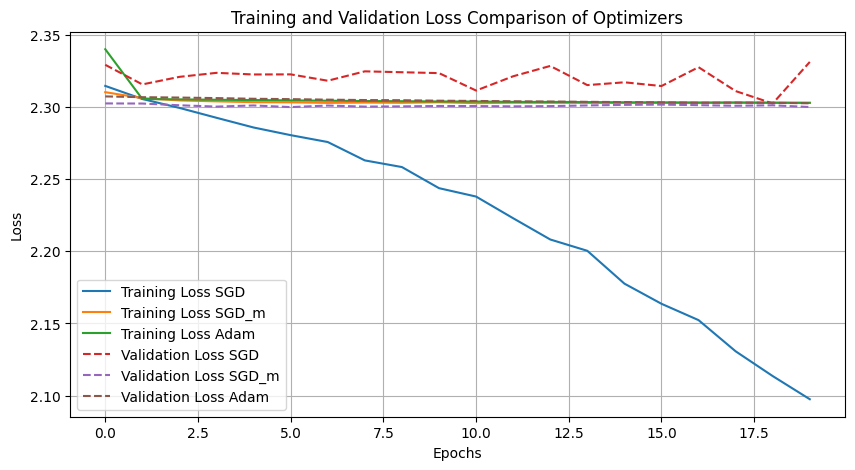

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
for keys, values in all_train_loss.items():
    ax.plot(values, label=f'Training Loss {keys}')
for keys, values in all_val_loss.items():
    ax.plot(values, label=f'Validation Loss {keys}', linestyle='--')

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss Comparison of Optimizers')
ax.legend()
plt.grid(True)
plt.show()

The lowest loss and fastest method looks SGD with momentum and Adam while SGD looks slightly flat and took more time (from the curve).

All three models are overfitted can see from the validation line.

ADAM takes twice the GPU memory than the SGD as it keeps in track of two parameters to update the learning rate according to the calculated gradient. For smaller dataset the adam optimizer is effective interms of fastest and smoother curve on loss calculated.

Training stability: add nn.BatchNorm1d after your
hidden layer OR nn.Dropout(0.3). Re-train and report the effect on validation
loss. Explain why the technique produces the effect you observe.

In [13]:
import torch.nn as nn
import torch.optim as optim
from torch.autograd import no_grad # Assuming no_grad is still used or needs to be imported

# Define the neural network architecture with optional Batch Normalization and Dropout
class FinalNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, is_batchnorm=False, is_dropout=False):
    super(FinalNN, self).__init__()
    # First linear layer mapping input to hidden size
    self.layer1 = nn.Linear(input_size, hidden_size)
    # Second linear layer mapping hidden size to output size
    self.layer2 = nn.Linear(hidden_size, output_size)

    # Store boolean flags for batch normalization and dropout
    self.is_batchnorm = is_batchnorm
    self.is_dropout = is_dropout

    # Initialize Batch Normalization layer if enabled
    # BatchNorm1d normalizes across the features, hidden_size here is the number of features
    if self.is_batchnorm:
        self.bn_layer = nn.BatchNorm1d(hidden_size)
    # Initialize Dropout layer if enabled
    if self.is_dropout:
        self.dropout_layer = nn.Dropout(0.3) # Dropout rate of 0.3

  def forward(self, x):
    # Pass through the first linear layer
    x = self.layer1(x)
    # Apply Batch Normalization if enabled (typically before activation for better performance)
    if self.is_batchnorm:
        x = self.bn_layer(x)
    # Apply ReLU activation function
    x = torch.relu(x)
    # Apply Dropout if enabled
    if self.is_dropout:
        x = self.dropout_layer(x)
    # Pass through the second linear layer to get final output
    x = self.layer2(x)
    return x

  def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):
    no_of_epoch = 20 # Number of training epochs
    train_losses = [] # List to store training loss per epoch
    val_losses = []   # List to store validation loss per epoch

    for epoch in range(no_of_epoch):
        # Set the model to training mode
        self.train()
        train_epoch_loss = 0.0
        for inputs, labels in train_loader:
            # Move data to the appropriate device (CPU/GPU)
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass: compute predicted outputs by passing inputs to the model
            output = self(inputs)
            # Calculate the loss
            loss = criterion(output, labels)

            # Zero the gradients of all optimized parameters
            optimizer.zero_grad()
            # Backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # Perform a single optimization step (parameter update)
            optimizer.step()

            # Accumulate training loss, scaled by batch size
            train_epoch_loss += loss.item() * inputs.size(0)
        # Calculate average training loss for the epoch
        train_epoch_loss /= len(train_loader.dataset)
        train_losses.append(train_epoch_loss)

        # Set the model to evaluation mode
        self.eval()
        val_epoch_loss = 0.0
        # Deactivate autograd for validation to save memory and computations
        with no_grad():
            for inputs, labels in val_loader:
                # Move data to the appropriate device
                inputs, labels = inputs.to(device), labels.to(device)
                # Forward pass
                output = self(inputs)
                # Calculate the loss
                loss = criterion(output, labels)

                # Accumulate validation loss, scaled by batch size
                val_epoch_loss += loss.item() * inputs.size(0)

            # Calculate average validation loss for the epoch
            val_epoch_loss /= len(val_loader.dataset)
            val_losses.append(val_epoch_loss)

        # Optional: Print epoch-wise loss (commented out for cleaner output during multiple runs)
        # print(f"Epoch {epoch+1}/{no_of_epoch}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")

    return train_losses, val_losses

# Helper function to train a model with specified regularization and optimizer
def train_model(model_instance, optimizer_class, lr, is_batchnorm=False, is_dropout=False):
    # Instantiate the model with appropriate flags
    model = FinalNN(INPUT_SIZE, 20, 10, is_batchnorm=is_batchnorm, is_dropout=is_dropout)
    model.to(device)

    # Define the loss function (CrossEntropyLoss is standard for multi-class classification)
    criterion = nn.CrossEntropyLoss()
    # Initialize the optimizer for the current model instance
    optimizer = optimizer_class(model.parameters(), lr=lr)

    # Train and evaluate the model
    train_loss, val_loss = model.train_and_evaluate(train_loader, val_loader, criterion, optimizer)
    return train_loss, val_loss

# --- Training Setup ---

# 1. Standard Model (No BatchNorm, No Dropout)
standard_train_loss, standard_val_loss = train_model(None, optim.Adam, 0.001, is_batchnorm=False, is_dropout=False)

# 2. Model with Batch Normalization
batchnorm_train_loss, batchnorm_val_loss = train_model(None, optim.Adam, 0.001, is_batchnorm=True, is_dropout=False)

# 3. Model with Dropout
dropout_train_loss, dropout_val_loss = train_model(None, optim.Adam, 0.001, is_batchnorm=False, is_dropout=True)


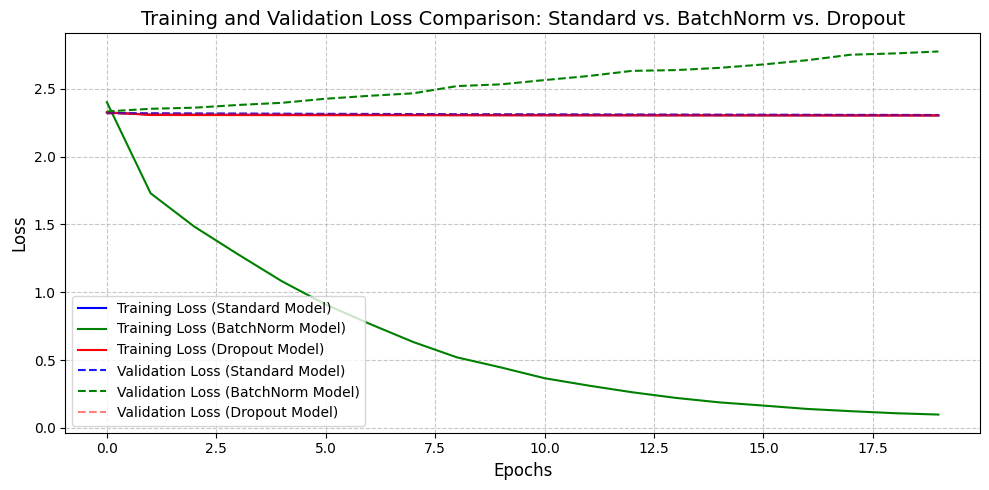

In [14]:
# Initialize a figure and an axes object for plotting
fig, ax = plt.subplots(figsize=(10, 5)) # Increased figure size for better visibility

# Plotting training losses
ax.plot(standard_train_loss, label='Training Loss (Standard Model)', color='blue', linestyle='-')
ax.plot(batchnorm_train_loss, label='Training Loss (BatchNorm Model)', color='green', linestyle='-')
ax.plot(dropout_train_loss, label='Training Loss (Dropout Model)', color='red', linestyle='-')

# Plotting validation losses
ax.plot(standard_val_loss, label='Validation Loss (Standard Model)', color='blue', linestyle='--' , alpha=0.9)
ax.plot(batchnorm_val_loss, label='Validation Loss (BatchNorm Model)', color='green', linestyle='--')
ax.plot(dropout_val_loss, label='Validation Loss (Dropout Model)', color='red', linestyle='--',  alpha=0.5)

# Set labels and title for the plot
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss Comparison: Standard vs. BatchNorm vs. Dropout', fontsize=14)

# Add a legend to distinguish the plots
ax.legend(loc='lower left', fontsize=10)

# Add a grid for better readability of values
ax.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
plt.show()

# Part A: Defect Type Classifier


In [15]:
import torch

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Torch Version: {torch.__version__}")

Using device: cuda
Torch Version: 2.11.0+cu128


1. Load the NEU dataset using
torchvision.datasets.ImageFolder and torch.utils.data.DataLoader. How many
images per class? What are the image dimensions?


In [29]:
# Importing datasets from kaggle
import kagglehub
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

train_path = path+'/NEU-DET/train/images'
val_path = path + '/NEU-DET/validation/images'
print(f"Train dataset path: {train_path}")
print(f"Validation dataset path: {val_path}")

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
Train dataset path: /kaggle/input/neu-surface-defect-database/NEU-DET/train/images
Validation dataset path: /kaggle/input/neu-surface-defect-database/NEU-DET/validation/images


In [62]:
from torchvision.datasets import ImageFolder
from collections import Counter

train_dataset = ImageFolder(root = train_path)
val_dataset = ImageFolder(root = val_path)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Train dataset classes: {train_dataset.classes}")
print(f"Validation dataset classes: {val_dataset.classes}")
print(f"Train dataset target counts: {Counter(train_dataset.targets)}")
print(f"Validation dataset target counts: {Counter(val_dataset.targets)}")


tarin_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

print(f"\nTrain loader length: {len(tarin_loader)}")
print(f"Validation loader length: {len(val_loader)}")

Train dataset size: 1440
Validation dataset size: 360
Train dataset classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Validation dataset classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Train dataset target counts: Counter({0: 240, 1: 240, 2: 240, 3: 240, 4: 240, 5: 240})
Validation dataset target counts: Counter({0: 60, 1: 60, 2: 60, 3: 60, 4: 60, 5: 60})

Train loader length: 45
Validation loader length: 12


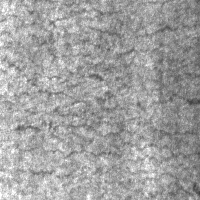

In [80]:
# Peek at first image
train_dataset[0][0]

In [85]:
# Create an iterator from dataset
data_iter = iter(train_dataset)

# Pull the very first batch off the belt
images, labels = next(data_iter)
print(images)
print(labels)
print(f"Image size: {images.size}")

<PIL.Image.Image image mode=RGB size=200x200 at 0x79F95BC4FD40>
0
Image size: (200, 200)


* Image is of size 200 x 200 with 3 channels (RGB) -(without transform)
* Train dataset count 1440, Validation dataset count 360.
* Total of 6 target class. 240 images per class in Train set and 60 images per class in Val set.
* With batches of 32 in dataloader, total lenth of train loader is 45 and val loader is 12.
* Images are not yet transformed into tensors.


2. Normalise pixel values using
torchvision.transforms.Normalize. Why is normalisation important before training
a CNN?

> Normalization is necessary to make uniform image pixel sizes.
> Pytorch tensors expects numbers on those grids instead of pictures. Normalizing tensors number with mean of 0.5 and std of 0.5 to make sure the range stays same in all differnt batches e.g., if batch 1 and 2 has different metrics/ mean std then model might be unstable or not generalize well.

In [87]:
# Using the path for train and val from above.
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((32,32)), # all image same size
    transforms.ToTensor(),  # iamge to tensors
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = ImageFolder(root = train_path, transform=transform)
val_dataset = ImageFolder(root = val_path, transform=transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

print(f"\nTrain loader length: {len(train_loader)}")
print(f"Validation loader length: {len(val_loader)}")

train_iter = iter(train_loader)
val_iter = iter(val_loader)

train_batch = next(train_iter)
val_batch = next(val_iter)

print(f"Train batch size: {train_batch[0].size()}")
print(f"Validation batch size: {val_batch[0].size()}")


Train dataset size: 1440
Validation dataset size: 360

Train loader length: 45
Validation loader length: 12
Train batch size: torch.Size([32, 3, 32, 32])
Validation batch size: torch.Size([32, 3, 32, 32])


The images are now set to train with 32 batch size, 3 channels and 32x32 size.

3.    Build a CNN classifier using nn.Module with at least:
    Conv2d → ReLU → MaxPool2d (×2) → Flatten → Linear output for 6 classes.

4.    Write a full PyTorch training loop:
    zero_grad() → forward() → CrossEntropyLoss → backward() → optimizer.step(). Train for 15 epochs.

In [96]:
import torch.nn.functional as F
import torch

class ClassifierCNN(nn.Module):
    def __init__(self,INPUT_SIZE=(3,32,32), no_of_classes=6):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)

        # ---- Used this as debugging the image flatten size -----
        # Calculate flattened size dynamically
        # dummy = torch.zeros(1, *INPUT_SIZE) # Create a dummy input tensor
        # x = self.pool(F.relu(self.conv1(dummy))) # Apply first conv, relu, and pool
        # x = self.pool(F.relu(self.conv2(x))) # Apply second conv, relu, and pool
        # flattened_size = x.view(1, -1).shape[1] # Flatten and get the size
        # print(f"DEBUG: Calculated flattened size: {flattened_size}") # Print for verification

        self.linear1 = nn.Linear(8*8*8, 64) #
        """ Original image 32,32 size.
         - kernel size 3, with padding 1 this preserves spatial dimensions
         - used MaxPool2d this reduce the dimension by half
         - image size after convolution and 2 * max pool = 32 / 2 * 2 = 8,8 size
         - conv2 returns 16 batch, 8 channels, 8,8 image size = 8*8*8
        """
        self.linear2 = nn.Linear(64, no_of_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        return x

    def train_and_evaluate(self, train_loader, val_loader):
        no_of_epoch = 15
        train_losses = []
        val_losses = []

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.parameters(), lr=0.001)

        # Training
        for epoch in range(no_of_epoch):
            self.train()
            train_epoch_loss = 0.0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                output = self(inputs)
                loss = criterion(output, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_epoch_loss += loss.item() * inputs.size(0)
            train_epoch_loss /= len(train_loader.dataset)
            train_losses.append(train_epoch_loss)

            # Validation
            self.eval()
            val_epoch_loss = 0.0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    output = self(inputs)
                    loss = criterion(output, labels)

                    val_epoch_loss += loss.item() * inputs.size(0)
            val_epoch_loss /= len(val_loader.dataset)
            val_losses.append(val_epoch_loss)
            print(f"Epoch {epoch+1}/{no_of_epoch}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
        return train_losses, val_losses

model = ClassifierCNN()
model.to(device)
train_losses, val_losses = model.train_and_evaluate(train_loader, val_loader)

Epoch 1/15, Train Loss: 1.5474, Val Loss: 1.6278
Epoch 2/15, Train Loss: 1.2835, Val Loss: 1.5188
Epoch 3/15, Train Loss: 1.0367, Val Loss: 1.3077
Epoch 4/15, Train Loss: 0.8707, Val Loss: 1.2238
Epoch 5/15, Train Loss: 0.8056, Val Loss: 1.1232
Epoch 6/15, Train Loss: 0.7263, Val Loss: 1.1441
Epoch 7/15, Train Loss: 0.6992, Val Loss: 1.0071
Epoch 8/15, Train Loss: 0.6160, Val Loss: 0.9469
Epoch 9/15, Train Loss: 0.6030, Val Loss: 1.2409
Epoch 10/15, Train Loss: 0.5404, Val Loss: 0.9636
Epoch 11/15, Train Loss: 0.5059, Val Loss: 0.7541
Epoch 12/15, Train Loss: 0.4716, Val Loss: 0.7132
Epoch 13/15, Train Loss: 0.4572, Val Loss: 0.8758
Epoch 14/15, Train Loss: 0.4157, Val Loss: 0.6908
Epoch 15/15, Train Loss: 0.3890, Val Loss: 0.7269


5.    Plot training vs. validation accuracy and loss. Is the model overfitting? At what epoch does it start?

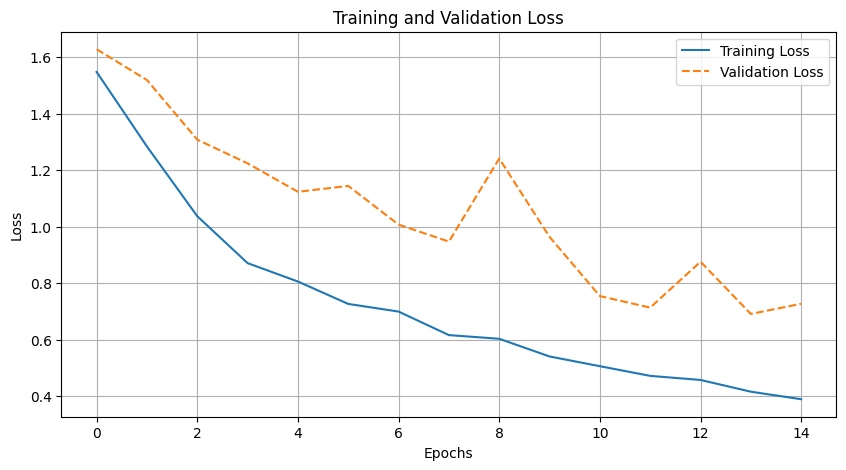

In [97]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Training Loss')
ax.plot(val_losses, label='Validation Loss', linestyle='--')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
plt.grid(True)
plt.show()

From the plot we can see, the train loss is decreasing gradually.
epoch 0-7, the validation and train loss decreasing gradually.
in the `epoch 8` the validation loss increased where training loss remain decreasing showing the model started to learn the training data set well including noise `Overfitting`. The train loss remains gradual decrease whereas the fluctuation can be seen in validation loss strong indicator of overfitted model.

6.    Per-class evaluation: which defect type has the lowest F1 score on the test set? Look at misclassified examples — why might crazing and patches be confused?